In [1]:
# Import de bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Dataset
df = pd.read_csv('./data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Data Processing
# A maioria dos campos vazios estão na coluna 'Age' e 'Embarked'
# Em vez de apagar, vamos preencher os valores vazios com a mediana (para 'Age') e o valor mais frequente (para 'Embarked')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convertemos também a coluna do género para valores binários (0 para masculino, 1 para feminino)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Selecionamos as colunas relevantes para o modelo e limpar resíduos
cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
df_limpo = df[cols].dropna()
print(df_limpo.head())

# Guardar o df para processamento posterior
df_limpo.to_csv('./data/Titanic-Dataset-Clean.csv', index=False)


   Survived  Pclass  Sex   Age  SibSp  Parch     Fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500


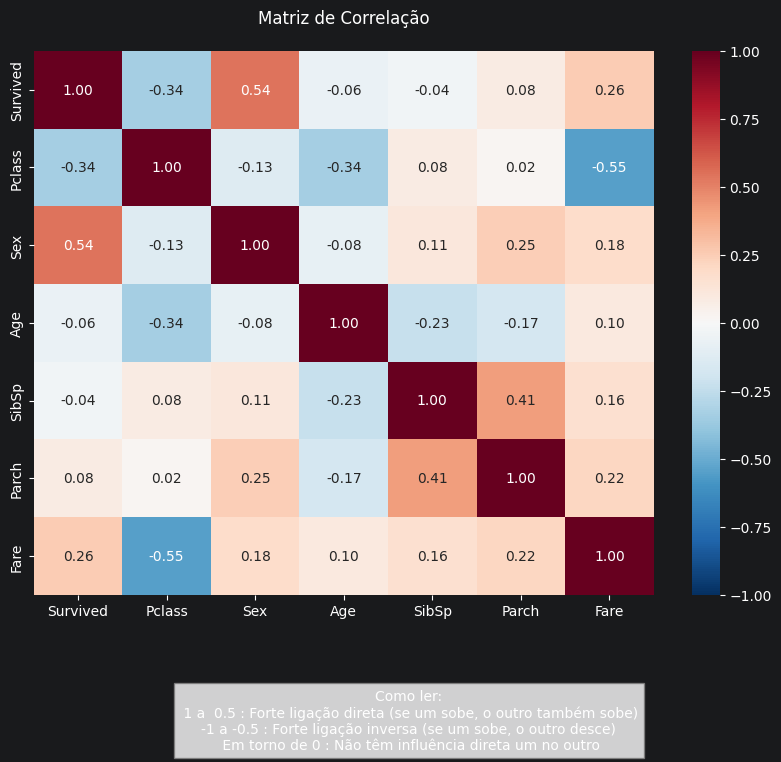

In [4]:
# Matriz de correlação e heatmap
corr_matrix = df_limpo.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r',
            fmt='.2f',
            linewidths=0,
            vmin=-1, vmax=1)

plt.title('Matriz de Correlação', pad=20)

# Adicionar a legenda descritiva (caption) no fundo
texto_legenda = (
    "Como ler:\n"
    " 1 a  0.5 : Forte ligação direta (se um sobe, o outro também sobe)\n"
    "-1 a -0.5 : Forte ligação inversa (se um sobe, o outro desce)\n"
    " Em torno de 0 : Não têm influência direta um no outro"
)
plt.figtext(0.5, 0.01, texto_legenda, wrap=True, horizontalalignment='center', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.subplots_adjust(bottom=0.2)
plt.show()

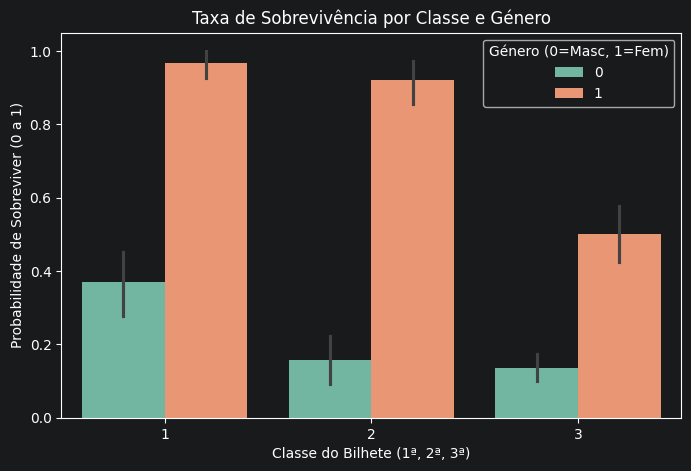

In [5]:
# Sobrevivência por género e classe
plt.figure(figsize=(8, 5))

# O gráfico de barras que mostra a probabilidade de sobrevivência, tendo em conta a classe e o género
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_limpo, palette='Set2')

plt.title('Taxa de Sobrevivência por Classe e Género')
plt.xlabel('Classe do Bilhete (1ª, 2ª, 3ª)')
plt.ylabel('Probabilidade de Sobreviver (0 a 1)')
plt.legend(title='Género (0=Masc, 1=Fem)')
plt.show()